# Aerogel Filtration ML --> Step 3: Baseline Random Forest

**What this notebook does:**
- Trains a quick Random Forest on both targets
- Reports R², RMSE, and MAE on a held-out test set
- Produces a first feature importance ranking
- Checks for signs of overfitting

## 3.1: Imports

In [16]:
!pip install scikit-learn matplotlib seaborn pandas numpy --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.inspection import permutation_importance

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

RANDOM_STATE = 42  # fixed seed for reproducible results

print('Libraries loaded.')

Libraries loaded.


## 3.2: Load preprocessed datasets

In [17]:
df_eff = pd.read_csv('model_data_filtration.csv')
df_qf  = pd.read_csv('model_data_qualityfactor.csv')

print(f'Filtration efficiency dataset:  {df_eff.shape[0]} samples, {df_eff.shape[1]} columns')
print(f'Quality factor dataset:         {df_qf.shape[0]} samples, {df_qf.shape[1]} columns')

Filtration efficiency dataset:  195 samples, 60 columns
Quality factor dataset:         82 samples, 60 columns


## 3.3: Define features and targets

In [18]:
# Columns that are targets or identifiers - NOT features
NON_FEATURE_COLS = [
    'sample_id',
    'filtration_efficiency (%)',
    'log_penetration',
    'quality_factor (mmH2O^-1)',
    'log_quality_factor',
    'pressure_drop (mmH2O/cm)',   # used to compute QF, not an independent predictor
]

def get_features(df):
    """Return feature columns: everything except targets and identifiers."""
    return [c for c in df.columns if c not in NON_FEATURE_COLS]

FEATURES_EFF = get_features(df_eff)
FEATURES_QF  = get_features(df_qf)

print(f'Features for filtration model:  {len(FEATURES_EFF)}')
print(f'Features for quality factor model: {len(FEATURES_QF)}')
print()
print('Feature list:')
for f in FEATURES_EFF:
    print(f'  {f}')

Features for filtration model:  57
Features for quality factor model: 57

Feature list:
  solid_content (g/100ml)
  log_skeletal_density (g/cm3)
  log_porosity (%)
  log_permeability (m2)
  bet_surface_area (m2/g)
  log_average_pore_size (nm)
  log_fiber_diameter (nm)
  log_airflow_rate (cm/s)
  log_sample_thickness (mm)
  log_average_particle_size (nm)
  contains_synthetic_polymer
  contains_inorganic
  contains_carbonaceous
  contains_polysaccharide
  contains_protein
  contains_fluoropolymer
  contains_silica
  contains_mof
  contains_silver
  contains_antimicrobial_additive
  contains_support_substrate
  is_commercial_reference
  architecture_descriptor_composite_filter
  architecture_descriptor_electrospun_nanofiber_membrane
  architecture_descriptor_fabric_supported_coating
  architecture_descriptor_fibrous_aerogel
  architecture_descriptor_monolithic_aerogel
  architecture_descriptor_multilayer_filter
  architecture_descriptor_nonwoven_fibrous_filter
  architecture_descriptor_pr

## 3.4: Helper functions

In [19]:
# These functions are reused for both targets.

def prepare_data(df, features, target_col):
    """
    Extract X (features) and y (target) from a dataframe.
    Only keeps rows where the target is not missing.
    For features: missing values are left as NaN — RandomForest
    in sklearn does NOT handle NaN natively, so we fill with median.
    (XGBoost in Step 4 will handle NaN natively — no filling needed there.)
    """
    valid = df[target_col].notna()
    X = df.loc[valid, features].copy()
    y = df.loc[valid, target_col].copy()

    # Fill missing feature values with column median
    
    X = X.fillna(X.median())

    return X, y


def evaluate(y_true, y_pred, label=''):
    """Print R², RMSE, and MAE for a set of predictions."""
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    print(f'{label}')
    print(f'  R²   = {r2:.4f}   (1.0 = perfect, 0.0 = no better than mean, <0 = worse than mean)')
    print(f'  RMSE = {rmse:.4f}')
    print(f'  MAE  = {mae:.4f}')
    return r2, rmse, mae


def plot_predicted_vs_actual(y_true, y_pred, title, filename):
    """Scatter plot of predicted vs actual values. Points on the diagonal = perfect."""
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(y_true, y_pred, alpha=0.55, s=30, color='steelblue', edgecolors='none')

    # Perfect prediction line
    lims = [min(y_true.min(), y_pred.min()) - 0.5,
            max(y_true.max(), y_pred.max()) + 0.5]
    ax.plot(lims, lims, 'r--', linewidth=1.2, label='Perfect prediction')

    r2 = r2_score(y_true, y_pred)
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_title(f'{title}\nR² = {r2:.3f}')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(filename, bbox_inches='tight')
    plt.show()
    print(f'Saved: {filename}')


def plot_feature_importance(model, features, title, filename, top_n=20):
    """
    Plot top N features by impurity-based importance.
    NOTE: this is a quick first look only.
    Step 5 (SHAP) gives the definitive, bias-corrected importance.
    Impurity-based importance can favour high-cardinality or
    continuous features — treat this as a rough guide.
    """
    importances = pd.Series(model.feature_importances_, index=features)
    importances = importances.sort_values(ascending=False).head(top_n)

    fig, ax = plt.subplots(figsize=(8, top_n * 0.38 + 1))
    colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(importances)))[::-1]
    bars = ax.barh(importances.index[::-1], importances.values[::-1],
                   color=colors[::-1], edgecolor='white')
    ax.set_xlabel('Impurity-based importance')
    ax.set_title(f'{title}\n(top {top_n} features — preliminary, see SHAP in Step 5)')
    for bar, val in zip(bars, importances.values[::-1]):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8)
    plt.tight_layout()
    plt.savefig(filename, bbox_inches='tight')
    plt.show()
    print(f'Saved: {filename}')


print('Helper functions defined.')

Helper functions defined.


## 3.5: Train/test split

In [20]:
# Filtration efficiency ─────────────────────────────────────────
# Target: 'log_penetration'
X_eff, y_eff = prepare_data(df_eff, FEATURES_EFF, 'log_penetration')

X_eff_train, X_eff_test, y_eff_train, y_eff_test = train_test_split(
    X_eff, y_eff, test_size=0.2, random_state=RANDOM_STATE
)

# Quality factor ────────────────────────────────────────────────
X_qf, y_qf = prepare_data(df_qf, FEATURES_QF, 'log_quality_factor')  

# Stratify by quantile bins so extreme values are spread evenly across train/test
qf_bins = pd.qcut(y_qf, q=4, labels=False, duplicates='drop')

X_qf_train, X_qf_test, y_qf_train, y_qf_test = train_test_split(
    X_qf, y_qf, test_size=0.2, random_state=RANDOM_STATE,
    stratify=qf_bins
)

print(f'Filtration efficiency — train: {len(X_eff_train)}, test: {len(X_eff_test)}')
print(f'Quality factor        — train: {len(X_qf_train)},  test: {len(X_qf_test)}')

Filtration efficiency — train: 156, test: 39
Quality factor        — train: 65,  test: 17


## 3.6: Train baseline Random Forest

In [21]:
# Random Forest parameters explained:
#
# n_estimators=500     - number of trees. More = more stable, slower.
#                         500 is a good balance for your dataset size.
# max_features='sqrt'  - each tree only sees sqrt(n_features) features.
#                         This is what makes trees different from each other.
# min_samples_leaf=2   - each leaf must have at least 2 samples.
#                         Prevents overfitting on tiny groups.
# oob_score=True       - out-of-bag score: a free internal validation
#                         estimate using samples not drawn for each tree.
#                         Useful for small datasets.
# n_jobs=-1            - use all CPU cores

RF_PARAMS = dict(
    n_estimators   = 500,
    max_features   = 'sqrt',
    min_samples_leaf = 2,
    oob_score      = True,
    random_state   = RANDOM_STATE,
    n_jobs         = -1
)

#  Model 1: Filtration efficiency ───────────────────────────────
print('Training RF for filtration efficiency...')
rf_eff = RandomForestRegressor(**RF_PARAMS)
rf_eff.fit(X_eff_train, y_eff_train)
print(f'  OOB R² (training set internal estimate): {rf_eff.oob_score_:.4f}')

#  Model 2: Quality factor ───────────────────────────────────────
print('Training RF for quality factor...')
rf_qf = RandomForestRegressor(**RF_PARAMS)
rf_qf.fit(X_qf_train, y_qf_train)
print(f'  OOB R² (training set internal estimate): {rf_qf.oob_score_:.4f}')

print('\nDone.')

Training RF for filtration efficiency...
  OOB R² (training set internal estimate): 0.6433
Training RF for quality factor...
  OOB R² (training set internal estimate): 0.3158

Done.


## 3.7: Evaluate on test set

In [22]:
# Predict on the held-out test set
# and compare R², RMSE, MAE on train vs test.
#
# What to look for:
#   Train R² >> Test R²  →  overfitting
#   Train R² ≈ Test R²   →  good generalization
#   Both R² low          →  underfitting

print('=' * 55)
print('FILTRATION EFFICIENCY')
print('=' * 55)
r2_eff_train, _, _ = evaluate(y_eff_train, rf_eff.predict(X_eff_train), 'Train set')
r2_eff_test,  _, _ = evaluate(y_eff_test,  rf_eff.predict(X_eff_test),  'Test set ')
print(f'  OOB R²               = {rf_eff.oob_score_:.4f}')
print(f'  Overfit gap (train-test R²) = {r2_eff_train - r2_eff_test:.4f}  ',
      '(>0.15 suggests overfitting)' if r2_eff_train - r2_eff_test > 0.15 else '(acceptable)')

print()
print('=' * 55)
print('QUALITY FACTOR')
print('=' * 55)
r2_qf_train, _, _ = evaluate(y_qf_train, rf_qf.predict(X_qf_train), 'Train set')
r2_qf_test,  _, _ = evaluate(y_qf_test,  rf_qf.predict(X_qf_test),  'Test set ')
print(f'  OOB R²               = {rf_qf.oob_score_:.4f}')
print(f'  Overfit gap (train-test R²) = {r2_qf_train - r2_qf_test:.4f}  ',
      '(>0.15 suggests overfitting)' if r2_qf_train - r2_qf_test > 0.15 else '(acceptable)')

FILTRATION EFFICIENCY
Train set
  R²   = 0.8248   (1.0 = perfect, 0.0 = no better than mean, <0 = worse than mean)
  RMSE = 1.3533
  MAE  = 1.0819
Test set 
  R²   = 0.7008   (1.0 = perfect, 0.0 = no better than mean, <0 = worse than mean)
  RMSE = 1.8123
  MAE  = 1.4850
  OOB R²               = 0.6433
  Overfit gap (train-test R²) = 0.1240   (acceptable)

QUALITY FACTOR
Train set
  R²   = 0.7076   (1.0 = perfect, 0.0 = no better than mean, <0 = worse than mean)
  RMSE = 0.4960
  MAE  = 0.2309
Test set 
  R²   = 0.7953   (1.0 = perfect, 0.0 = no better than mean, <0 = worse than mean)
  RMSE = 0.4264
  MAE  = 0.2353
  OOB R²               = 0.3158
  Overfit gap (train-test R²) = -0.0877   (acceptable)


## 3.8: Predicted vs actual plots

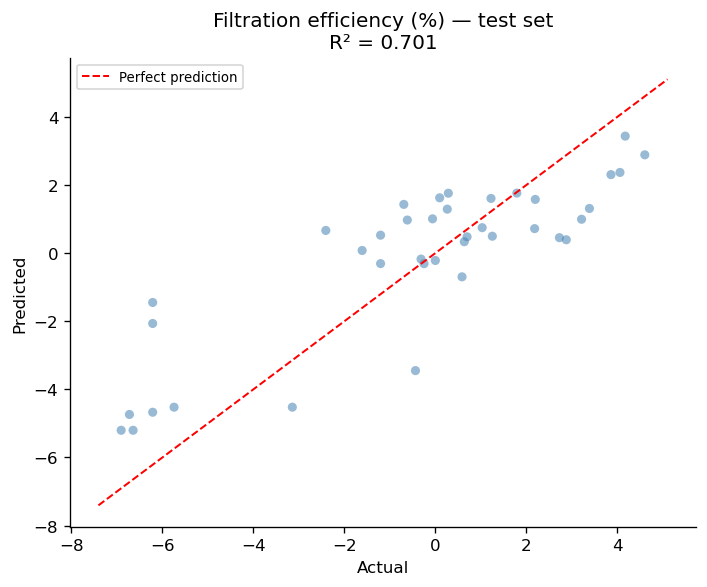

Saved: baseline_rf_predicted_vs_actual_filtration.png


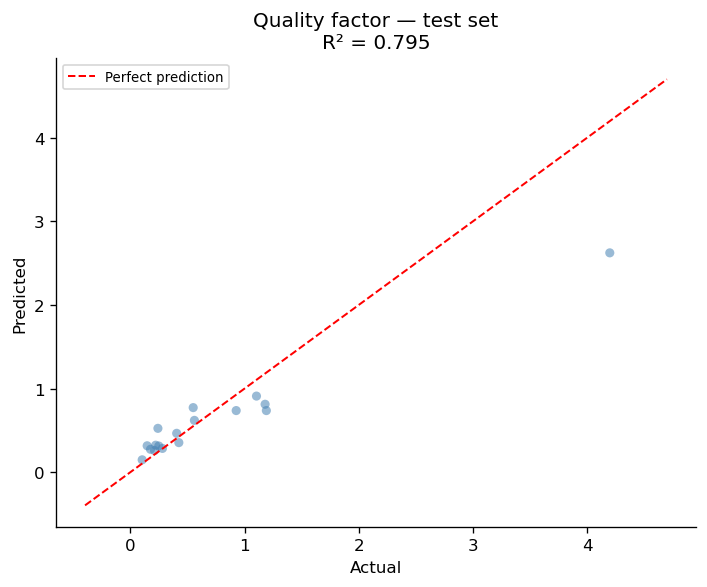

Saved: baseline_rf_predicted_vs_actual_qf.png


In [23]:
# Points close to the red dashed diagonal = good predictions.
# Systematic curves or fan shapes = non-linear patterns or
# heteroscedasticity (variance increases with value).

plot_predicted_vs_actual(
    y_eff_test,
    rf_eff.predict(X_eff_test),
    'Filtration efficiency (%) — test set',
    'baseline_rf_predicted_vs_actual_filtration.png'
)

plot_predicted_vs_actual(
    y_qf_test,
    rf_qf.predict(X_qf_test),
    'Quality factor — test set',
    'baseline_rf_predicted_vs_actual_qf.png'
)

## 3.9: Cross-validated R² 

In [24]:
from sklearn.model_selection import KFold, StratifiedKFold

rf_cv = RandomForestRegressor(**RF_PARAMS)

# Filtration efficiency - stratified 5-fold CV
# stratified on quartile bins of log_penetration to prevent accidental
# test-variance collapse 
eff_bins = pd.qcut(y_eff, q=4, labels=False, duplicates='drop')
skf_eff = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print('Running 5-fold stratified CV for filtration efficiency...')
cv_scores_eff = cross_val_score(
    rf_cv, X_eff, y_eff,
    cv=skf_eff.split(X_eff, eff_bins),
    scoring='r2', n_jobs=-1
)
print(f'  Fold R² scores: {[round(s, 3) for s in cv_scores_eff]}')
print(f'  Mean R²: {cv_scores_eff.mean():.4f} ± {cv_scores_eff.std():.4f}')

print()

# Quality factor - stratified 5-fold CV (unchanged) 
qf_bins = pd.qcut(y_qf, q=4, labels=False, duplicates='drop')
skf_qf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print('Running 5-fold stratified CV for quality factor...')
cv_scores_qf = cross_val_score(
    rf_cv, X_qf, y_qf,
    cv=skf_qf.split(X_qf, qf_bins),
    scoring='r2', n_jobs=-1
)
print(f'  Fold R² scores: {[round(s, 3) for s in cv_scores_qf]}')
print(f'  Mean R²: {cv_scores_qf.mean():.4f} ± {cv_scores_qf.std():.4f}')

print()
print('NOTE: Both targets are on log-transformed scales.')
print('Expect filtration CV R² ~ 0.55-0.70, QF CV R² ~ 0.4-0.6')
print('(QF has higher variance due to n=82).')


Running 5-fold stratified CV for filtration efficiency...
  Fold R² scores: [0.621, 0.551, 0.746, 0.732, 0.657]
  Mean R²: 0.6615 ± 0.0721

Running 5-fold stratified CV for quality factor...
  Fold R² scores: [0.296, 0.437, 0.569, 0.019, 0.718]
  Mean R²: 0.4077 ± 0.2395

NOTE: Both targets are on log-transformed scales.
Expect filtration CV R² ~ 0.55-0.70, QF CV R² ~ 0.4-0.6
(QF has higher variance due to n=82).


## 3.10: Feature importance (preliminary)

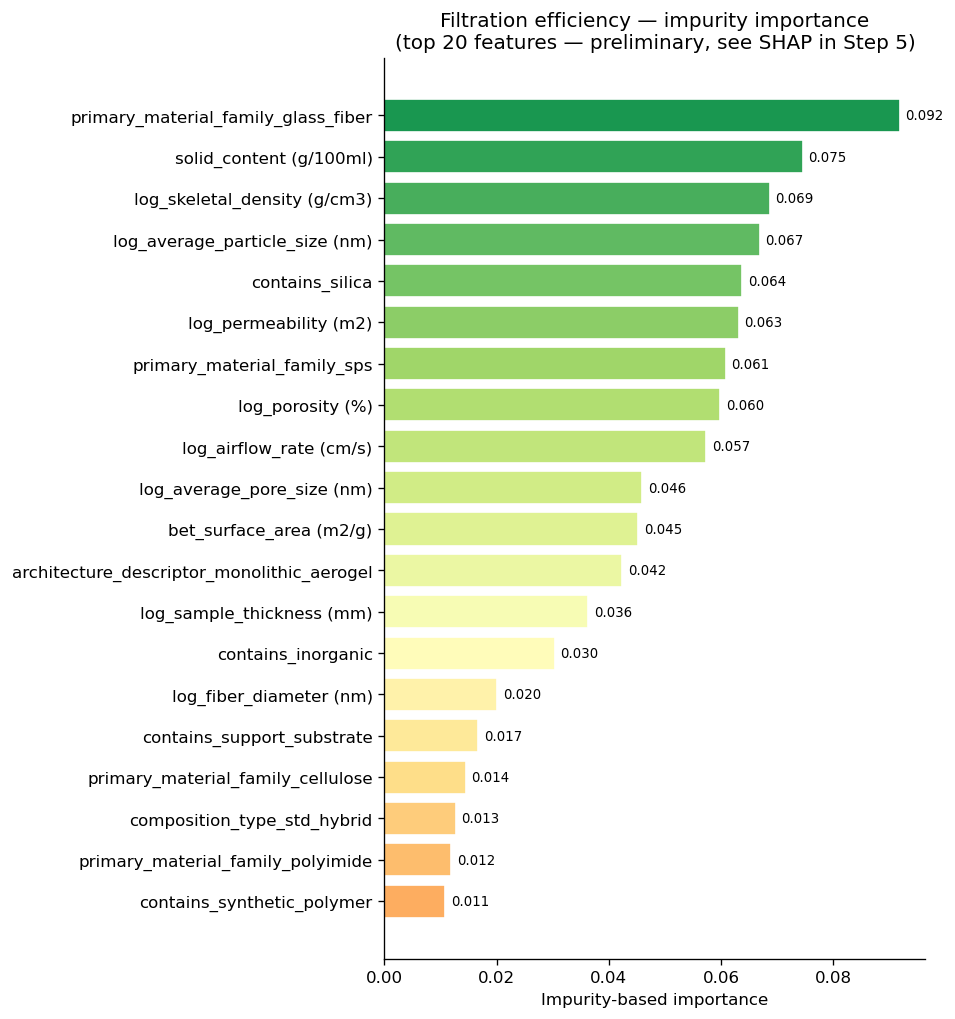

Saved: baseline_rf_importance_filtration.png


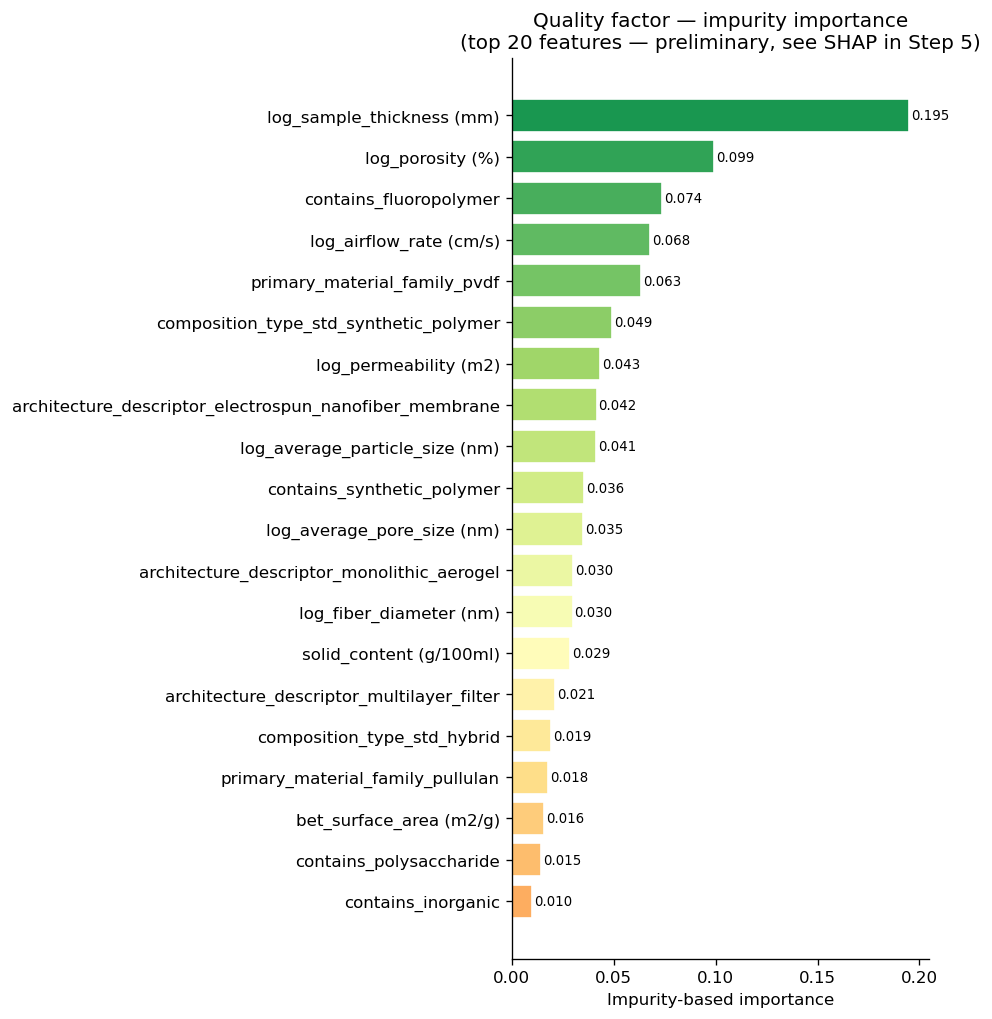

Saved: baseline_rf_importance_qf.png


In [25]:
# First look at which features the RF finds important.
# This uses impurity-based importance (built into sklearn RF).
#
# IMPORTANT :
# Impurity-based importance is biased toward continuous and high-cardinality features.
# and it can overstate the importance of features like airflow_rate
# just because they have many unique values.
# Step 5 (SHAP) will correct this. 
plot_feature_importance(
    rf_eff, FEATURES_EFF,
    'Filtration efficiency — impurity importance',
    'baseline_rf_importance_filtration.png',
    top_n=20
)

plot_feature_importance(
    rf_qf, FEATURES_QF,
    'Quality factor — impurity importance',
    'baseline_rf_importance_qf.png',
    top_n=20
)

## 3.11: Permutation importance (less biased)

In [26]:
print('Computing permutation importance for filtration efficiency...')
perm_eff = permutation_importance(
    rf_eff, X_eff_test, y_eff_test,
    n_repeats=30,          # shuffle each feature 30 times and average
    random_state=RANDOM_STATE,
    n_jobs=-1
)

print('Computing permutation importance for quality factor...')
perm_qf = permutation_importance(
    rf_qf, X_qf_test, y_qf_test,
    n_repeats=30,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
print('Done.')

Computing permutation importance for filtration efficiency...
Computing permutation importance for quality factor...
Done.


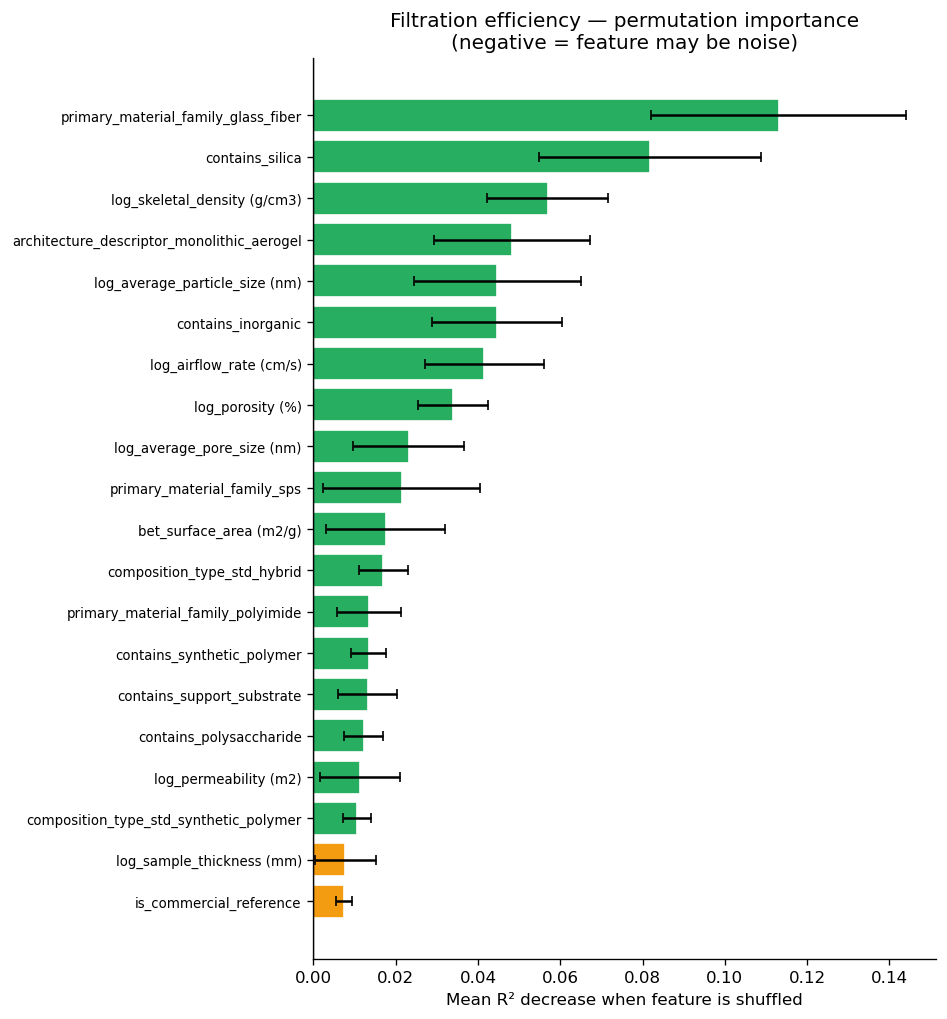

Saved: baseline_rf_permutation_filtration.png


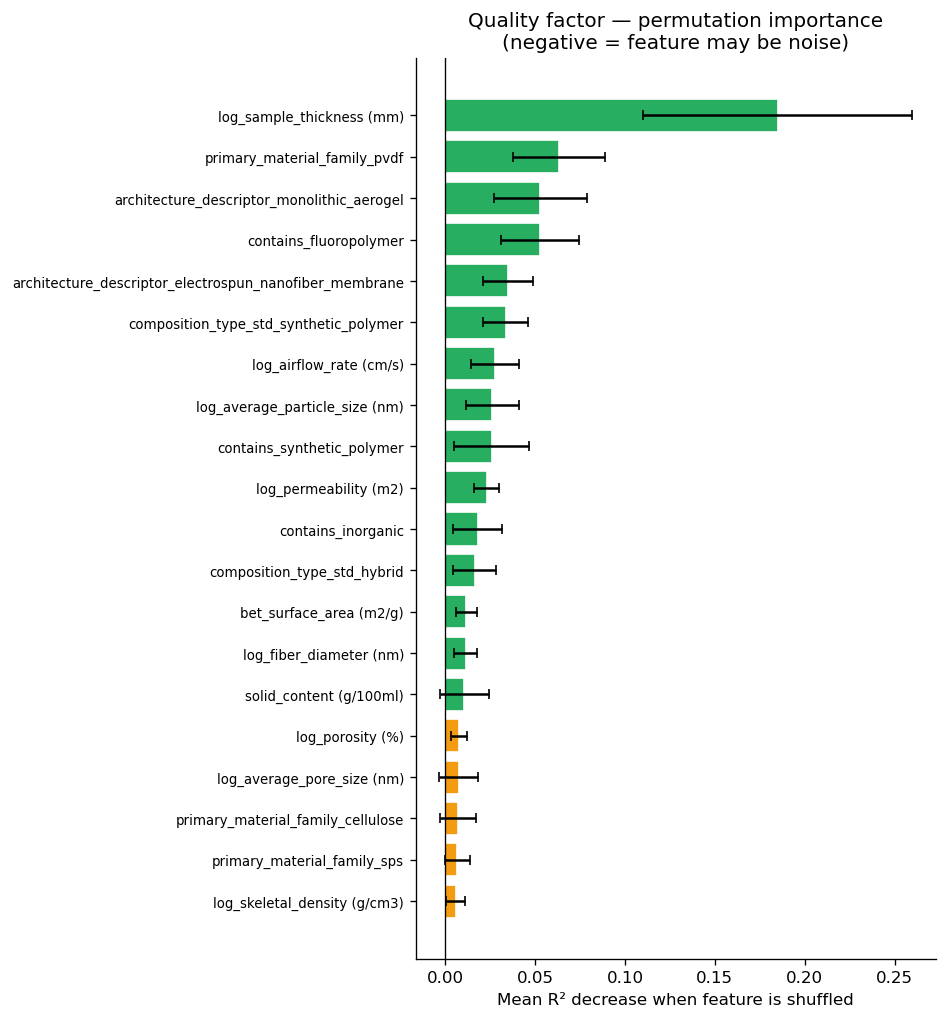

Saved: baseline_rf_permutation_qf.png


In [27]:
def plot_permutation_importance(perm_result, features, title, filename, top_n=20):
    """
    Plot permutation importance with error bars.
    Error bars show variability across the 30 shuffles.
    Features with importance near zero = not contributing to predictions.
    """
    imp_mean = perm_result.importances_mean
    imp_std  = perm_result.importances_std

    # Sort by mean importance, take top N
    idx = np.argsort(imp_mean)[::-1][:top_n]
    top_features = [features[i] for i in idx]
    top_means    = imp_mean[idx]
    top_stds     = imp_std[idx]

    fig, ax = plt.subplots(figsize=(8, top_n * 0.38 + 1))
    colors = ['#e74c3c' if m < 0 else '#27ae60' if m > 0.01 else '#f39c12'
              for m in top_means]
    ax.barh(
        range(top_n), top_means[::-1],
        xerr=top_stds[::-1],
        color=colors[::-1],
        edgecolor='white',
        capsize=3
    )
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(top_features[::-1], fontsize=8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Mean R² decrease when feature is shuffled')
    ax.set_title(f'{title}\n(negative = feature may be noise)')
    plt.tight_layout()
    plt.savefig(filename, bbox_inches='tight')
    plt.show()
    print(f'Saved: {filename}')

    neg = [(top_features[i], top_means[i]) for i in range(len(top_features))
           if top_means[i] < 0]
    if neg:
        print('Features with negative permutation importance (possibly noise):')
        for name, val in neg:
            print(f'  {name}: {val:.4f}')

plot_permutation_importance(
    perm_eff, FEATURES_EFF,
    'Filtration efficiency — permutation importance',
    'baseline_rf_permutation_filtration.png'
)

plot_permutation_importance(
    perm_qf, FEATURES_QF,
    'Quality factor — permutation importance',
    'baseline_rf_permutation_qf.png'
)

## 3.12: Residual analysis

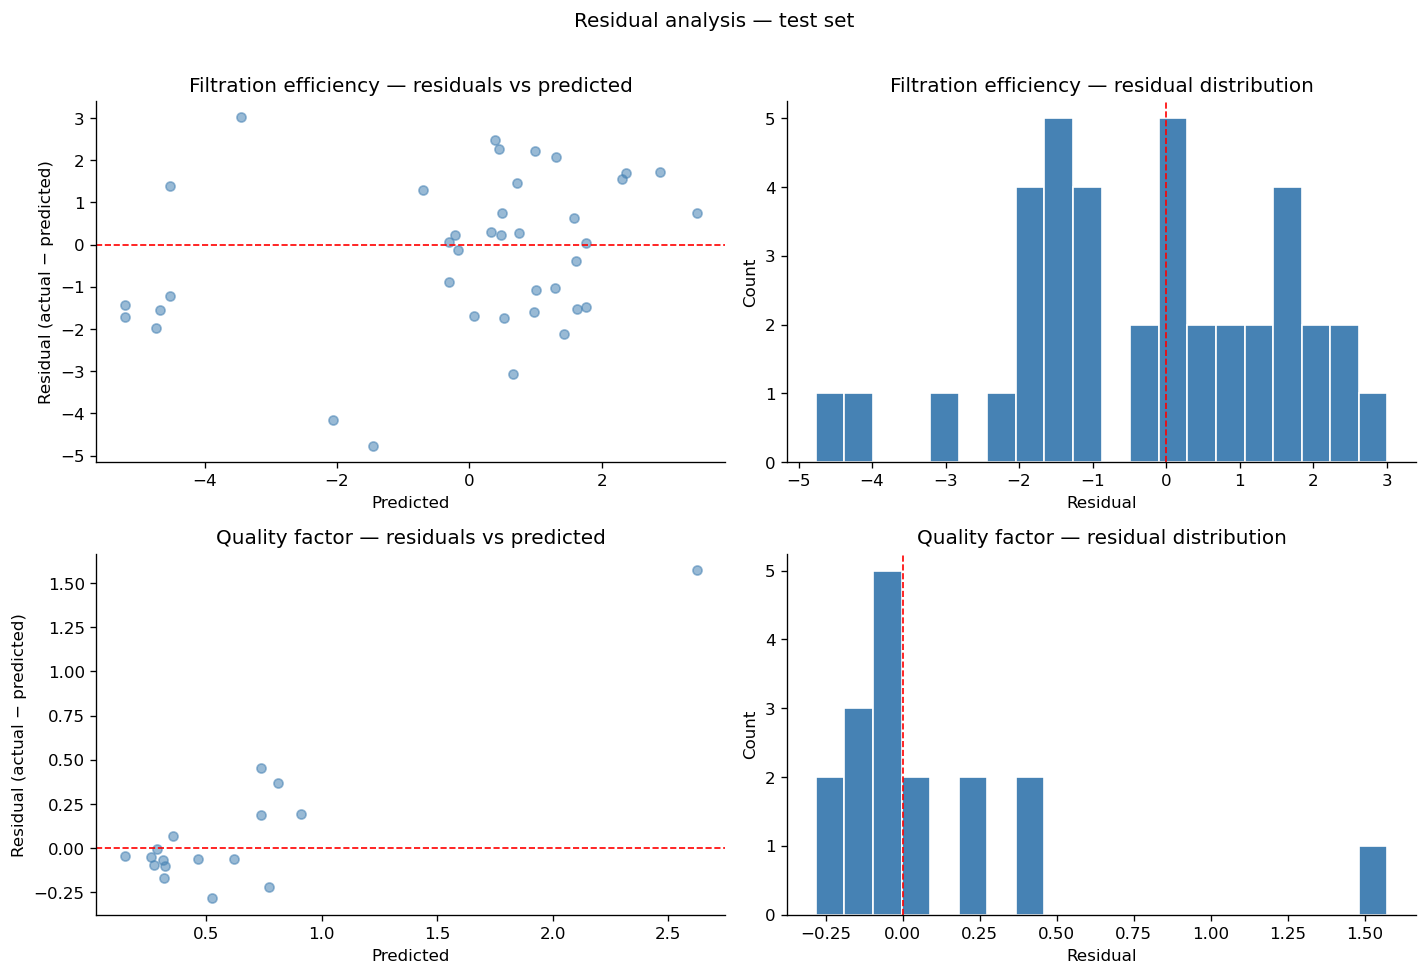

Saved: baseline_rf_residuals.png


In [28]:
# Residuals = actual - predicted

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for row, (y_true, y_pred, label) in enumerate([
    (y_eff_test, rf_eff.predict(X_eff_test), 'Filtration efficiency'),
    (y_qf_test,  rf_qf.predict(X_qf_test),  'Quality factor'),
]):
    residuals = y_true.values - y_pred

    # Residuals vs predicted
    ax = axes[row, 0]
    ax.scatter(y_pred, residuals, alpha=0.55, s=30, color='steelblue')
    ax.axhline(0, color='red', linestyle='--', linewidth=1)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Residual (actual − predicted)')
    ax.set_title(f'{label} — residuals vs predicted')

    # Residual histogram
    ax = axes[row, 1]
    ax.hist(residuals, bins=20, color='steelblue', edgecolor='white')
    ax.axvline(0, color='red', linestyle='--', linewidth=1)
    ax.set_xlabel('Residual')
    ax.set_ylabel('Count')
    ax.set_title(f'{label} — residual distribution')

plt.suptitle('Residual analysis — test set', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('baseline_rf_residuals.png', bbox_inches='tight')
plt.show()
print('Saved: baseline_rf_residuals.png')

## 3.13: Step 3 summary

In [29]:
print('STEP 3 BASELINE SUMMARY (log-transformed targets)')
print('=' * 55)
print(f'Filtration efficiency (target: log_penetration)')
print(f'  Test R²:  {r2_score(y_eff_test, rf_eff.predict(X_eff_test)):.4f}')
print(f'  OOB R²:   {rf_eff.oob_score_:.4f}')
print(f'  CV R²:    {cv_scores_eff.mean():.4f} ± {cv_scores_eff.std():.4f}')
print()
print(f'Quality factor (target: log_quality_factor)')
print(f'  Test R²:  {r2_score(y_qf_test, rf_qf.predict(X_qf_test)):.4f}')
print(f'  OOB R²:   {rf_qf.oob_score_:.4f}')
print(f'  CV R²:    {cv_scores_qf.mean():.4f} ± {cv_scores_qf.std():.4f}')
print()
print('Interpretation guide (log scale):')
print('  R² > 0.70  — strong signal, proceed confidently to Step 4')
print('  R² 0.50-0.70 — moderate signal, acceptable for heterogeneous dataset')
print('  R² 0.30-0.50 — weak signal, discuss in paper as expected given data diversity')
print('  R² < 0.30  — revisit feature set or check for data issues before Step 4')
print()
print('Next: Step 4 — Nested cross-validation with RF + XGBoost + LASSO')


STEP 3 BASELINE SUMMARY (log-transformed targets)
Filtration efficiency (target: log_penetration)
  Test R²:  0.7008
  OOB R²:   0.6433
  CV R²:    0.6615 ± 0.0721

Quality factor (target: log_quality_factor)
  Test R²:  0.7953
  OOB R²:   0.3158
  CV R²:    0.4077 ± 0.2395

Interpretation guide (log scale):
  R² > 0.70  — strong signal, proceed confidently to Step 4
  R² 0.50-0.70 — moderate signal, acceptable for heterogeneous dataset
  R² 0.30-0.50 — weak signal, discuss in paper as expected given data diversity
  R² < 0.30  — revisit feature set or check for data issues before Step 4

Next: Step 4 — Nested cross-validation with RF + XGBoost + LASSO
